In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# project root = two levels above notebooks
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

In [24]:
from src.data.data_loading import (
    load_full_dataset,
    load_full_training_pool,
    load_test_data,
    load_training_data,
    load_validation_data
)

df = load_full_dataset()
removed_columns = ['spatial_cluster', 'is_test', 'cv_fold']
df = df.drop(columns= removed_columns)

In [25]:
rows_per_fsa = {}
for fsa in df.FSA.unique():
    rows_per_fsa[fsa] = len(df[df.FSA == fsa])
rows_per_fsa_df = pd.DataFrame({'FSA': rows_per_fsa.keys(), 'no_of_rows': rows_per_fsa.values()})

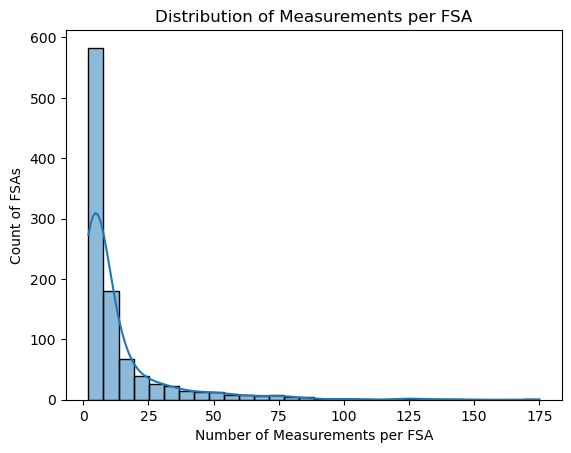

In [13]:
plt.figure()
sns.histplot(rows_per_fsa_df["no_of_rows"], bins=30, kde=True)
plt.xlabel("Number of Measurements per FSA")
plt.ylabel("Count of FSAs")
plt.title("Distribution of Measurements per FSA")
plt.show()

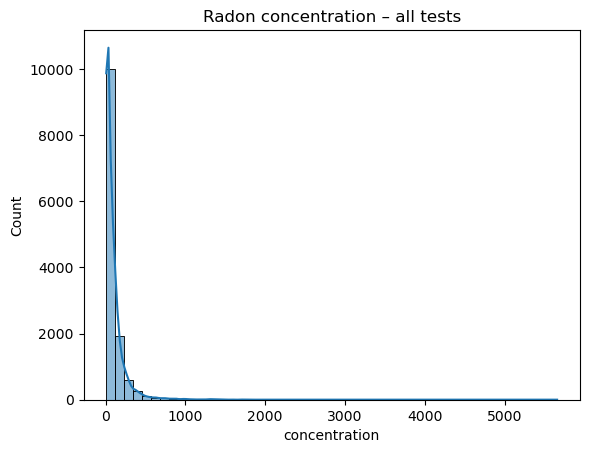

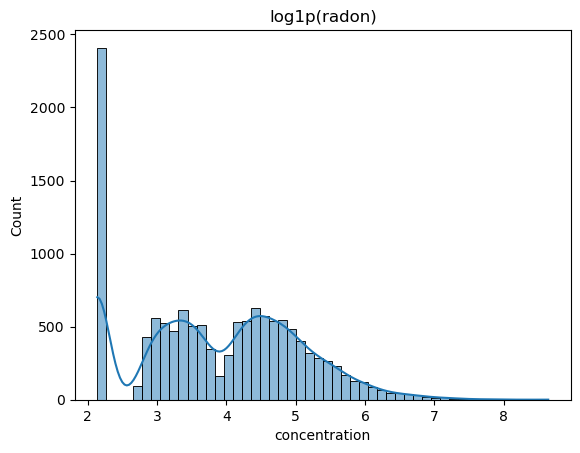

0.00       7.50
0.01       7.50
0.05       7.50
0.10       7.50
0.25      19.00
0.50      48.00
0.75     115.00
0.90     218.00
0.95     317.00
0.99     741.48
1.00    5657.00
Name: concentration, dtype: float64

In [14]:
target = "concentration"        # whatever column holds the radon value
sns.histplot(df[target], bins=50, kde=True);
plt.title("Radon concentration – all tests");
plt.show()

# log‑scale if highly skewed
sns.histplot(np.log1p(df[target]), bins=50, kde=True);
plt.title("log1p(radon)");
plt.show()

# look at percentiles
df[target].quantile([0,.01,.05,.1,.25,.5,.75,.9,.95,.99,1])

In [28]:
corr

,n_days,longitude,latitude,hous_frac_type_single_detached,hous_frac_type_highrise,hous_frac_type_other_attached,hous_frac_type_movable,hous_avg_rooms,hous_frac_major_repair,hous_frac_age_pre_1980,...,sedi_glaciolacustrine_sediments,sedi_glaciomarine_sediments,sedi_lacustrine_sediments,sedi_marine_sediments,sedi_organic_deposits,sedi_volcanic_deposits,sedi_weathered_bedrock_or_regolith,average_heating_days,mean_uranium,max_uranium
n_days,1.000000,0.047273,-0.029314,-0.027963,0.041168,0.016603,-0.002937,-0.011867,-0.014409,0.003637,...,-0.004664,0.002578,0.001901,0.009850,-0.014699,-0.004831,NaN,-0.008214,-0.025207,-0.009231
longitude,0.047273,1.000000,-0.609574,0.114865,0.049477,-0.024722,-0.396984,-0.002474,-0.148223,0.201176,...,-0.198380,0.125685,0.066923,0.225141,-0.108019,-0.084817,NaN,-0.127893,-0.421795,-0.194275
latitude,-0.029314,-0.609574,1.000000,0.016347,-0.252829,-0.101661,0.577977,-0.210335,0.455713,-0.146782,...,0.078829,-0.084366,-0.242157,-0.046426,0.196776,0.031116,NaN,0.652705,0.189911,0.360120
hous_frac_type_single_detached,-0.027963,0.114865,0.016347,1.000000,-0.554357,-0.922378,0.017965,0.548961,0.306892,0.013878,...,-0.071264,-0.086910,0.066317,0.072680,0.164060,-0.042275,NaN,0.053097,0.099697,0.204778
hous_frac_type_highrise,0.041168,0.049477,-0.252829,-0.554357,1.000000,0.311310,-0.228706,-0.341464,-0.164324,0.103421,...,0.112138,-0.059124,0.064702,-0.056999,-0.079398,-0.005607,NaN,-0.269430,-0.106532,-0.117637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sedi_volcanic_deposits,-0.004831,-0.084817,0.031116,-0.042275,-0.005607,0.046897,0.009952,-0.041556,0.005320,-0.048375,...,-0.033728,-0.016257,-0.010277,-0.009313,-0.011971,1.000000,NaN,0.026887,0.077337,0.011700
sedi_weathered_bedrock_or_regolith,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_heating_days,-0.008214,-0.127893,0.652705,0.053097,-0.269430,-0.078567,0.392180,-0.218658,0.343181,-0.013849,...,-0.277782,-0.015811,-0.188417,0.180956,0.026824,0.026887,NaN,1.000000,0.002215,0.299895
mean_uranium,-0.025207,-0.421795,0.189911,0.099697,-0.106532,-0.147344,0.217993,0.248819,-0.053948,0.008161,...,0.093677,-0.189767,-0.004006,-0.011468,-0.075207,0.077337,NaN,0.002215,1.000000,0.085642


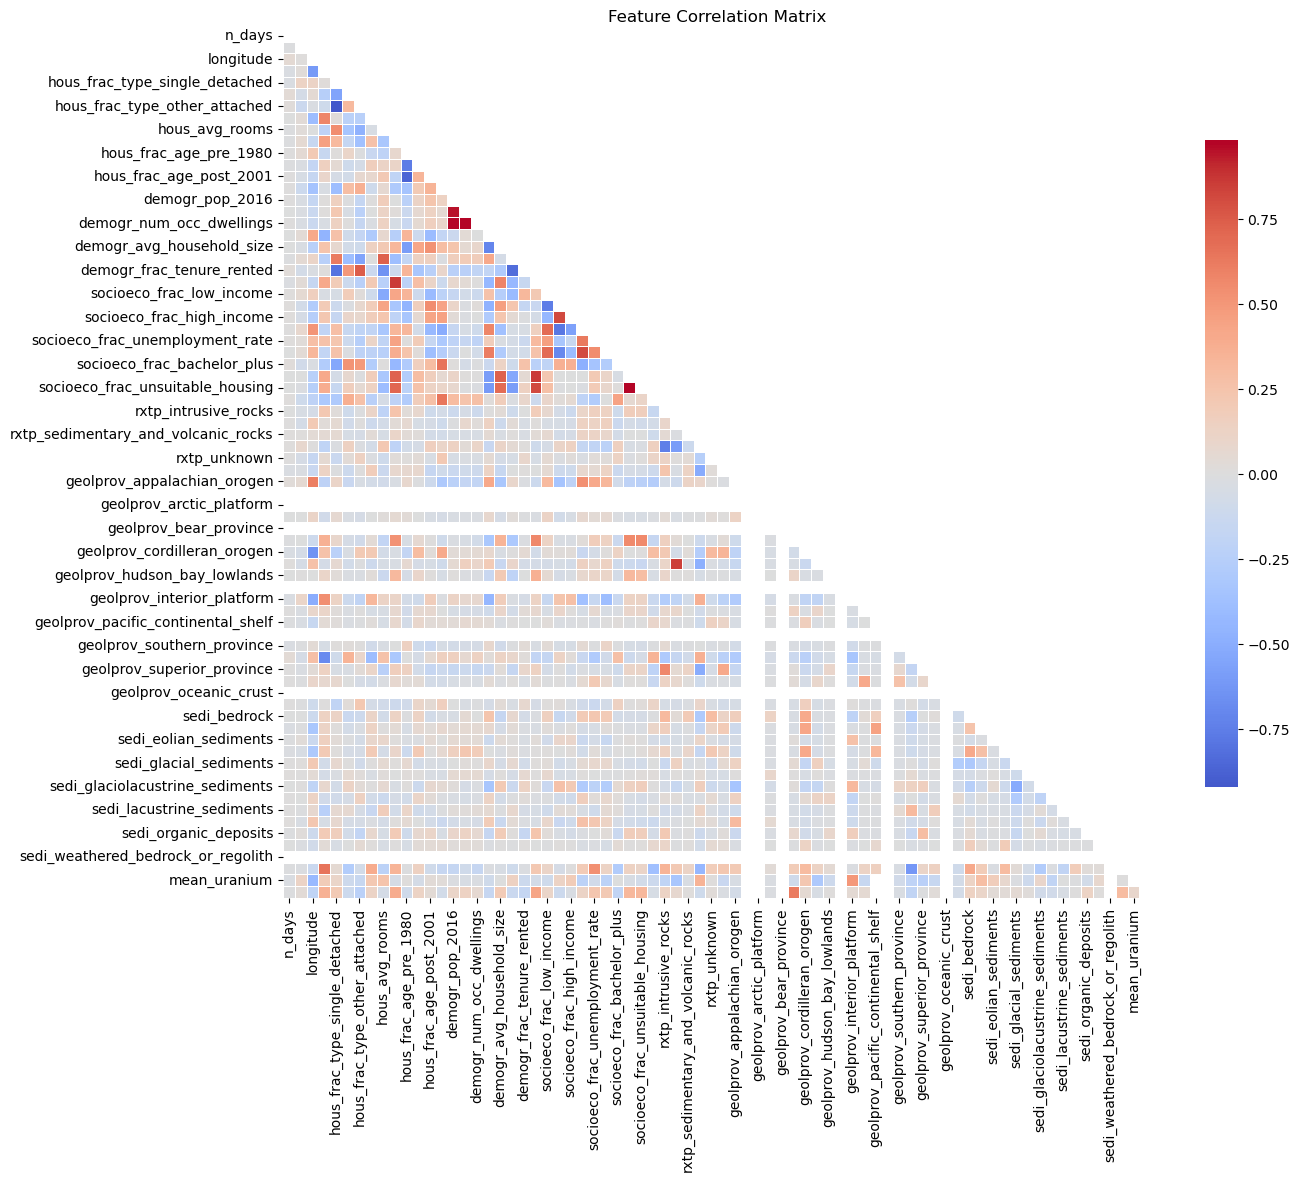

In [51]:
# numeric features only
num = df.select_dtypes(include="number")

corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .7}
)

plt.title("Feature Correlation Matrix")
plt.show()

In [59]:
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.head(40))

demogr_num_occ_dwellings          demogr_pop_2016                     0.981500
demogr_pop_2016                   demogr_num_occ_dwellings            0.981500
demogr_num_total_dwellings        demogr_num_occ_dwellings            0.978219
demogr_num_occ_dwellings          demogr_num_total_dwellings          0.978219
socioeco_frac_overcrowded         socioeco_frac_unsuitable_housing    0.969734
socioeco_frac_unsuitable_housing  socioeco_frac_overcrowded           0.969734
demogr_num_total_dwellings        demogr_pop_2016                     0.950072
demogr_pop_2016                   demogr_num_total_dwellings          0.950072
hous_frac_type_other_attached     hous_frac_type_single_detached      0.922378
hous_frac_type_single_detached    hous_frac_type_other_attached       0.922378
hous_frac_age_post_2001           hous_frac_age_pre_1980              0.862991
hous_frac_age_pre_1980            hous_frac_age_post_2001             0.862991
socioeco_frac_overcrowded         demogr_frac_tenure

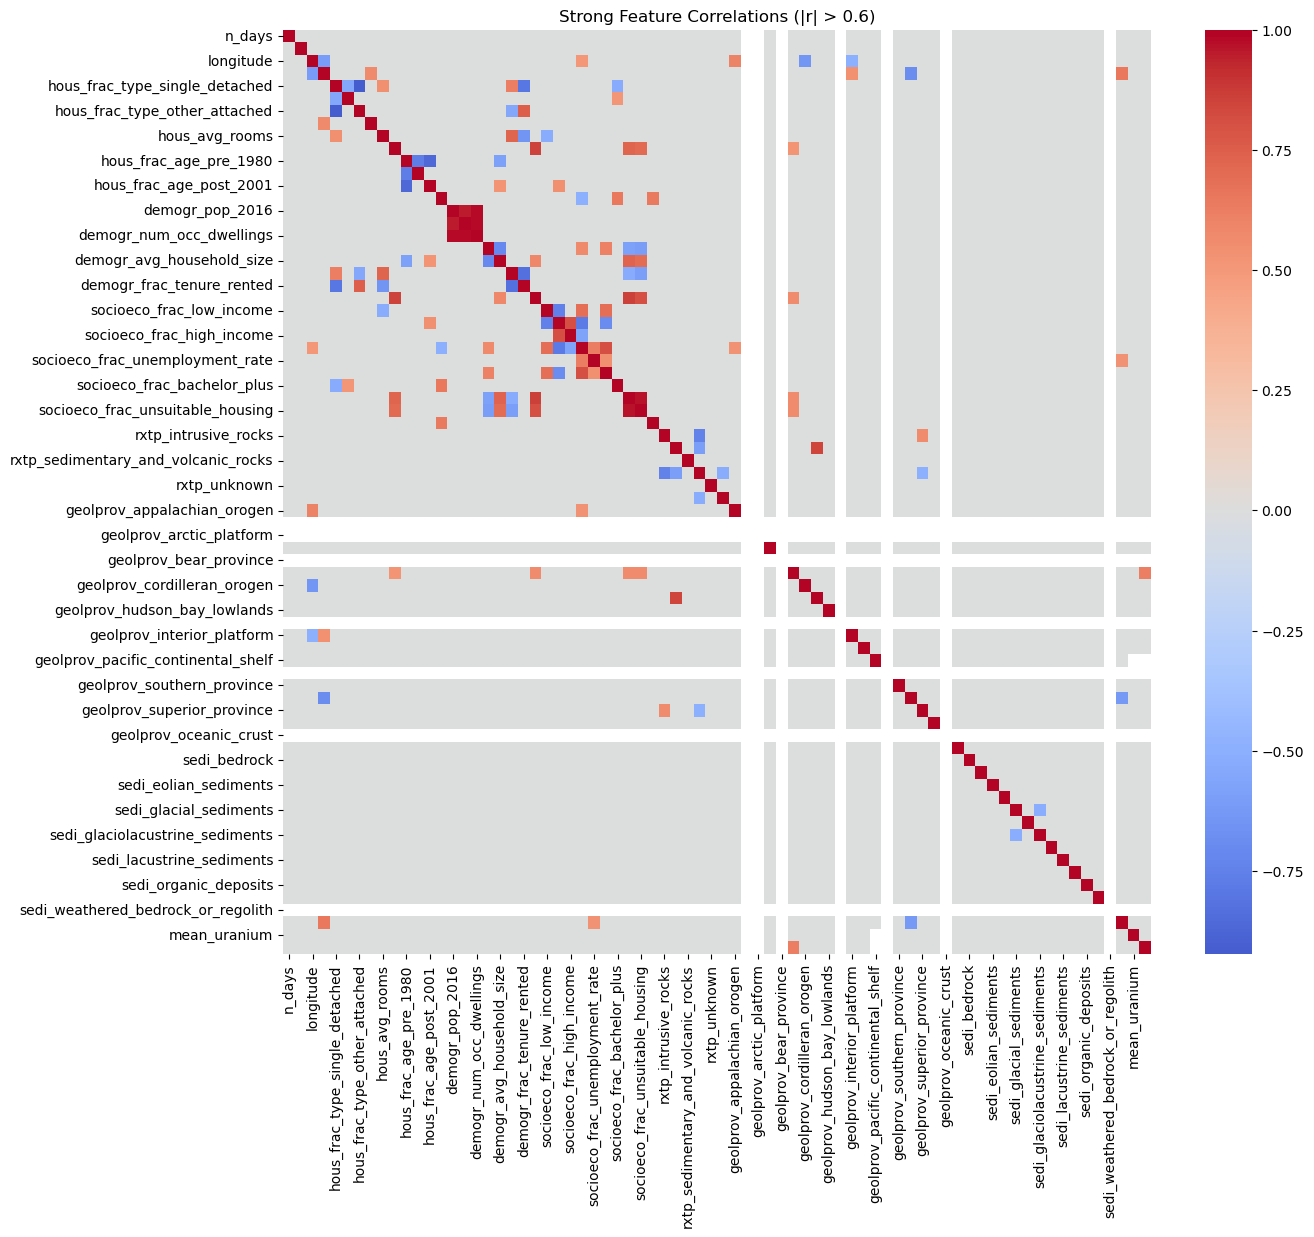

In [ ]:
corr_filtered = corr.copy()
corr_filtered[np.abs(corr_filtered) < 0.5] = 0

plt.figure(figsize=(14,12))
sns.heatmap(corr_filtered, cmap="coolwarm", center=0)
plt.title("Strong Feature Correlations (|r| > 0.5)")
plt.show()

In [63]:
conc_corr = corr['concentration']
strong_corr = conc_corr[abs(conc_corr) >= 0.1].sort_values(ascending=False)
print(strong_corr)

concentration                     1.000000
hous_frac_type_single_detached    0.120715
mean_uranium                      0.113790
geolprov_interior_platform        0.100746
socioeco_frac_housing_burden     -0.100519
hous_median_value                -0.112431
hous_frac_type_other_attached    -0.121414
Name: concentration, dtype: float64


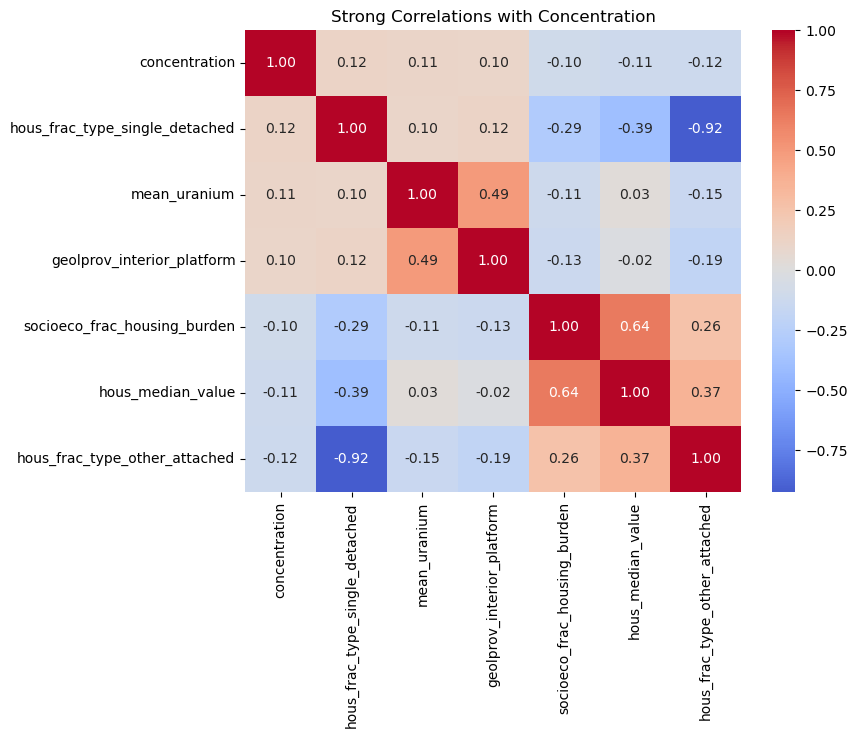

In [64]:
selected_features = strong_corr.index
corr_subset = df[selected_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_subset,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Strong Correlations with Concentration")
plt.show()

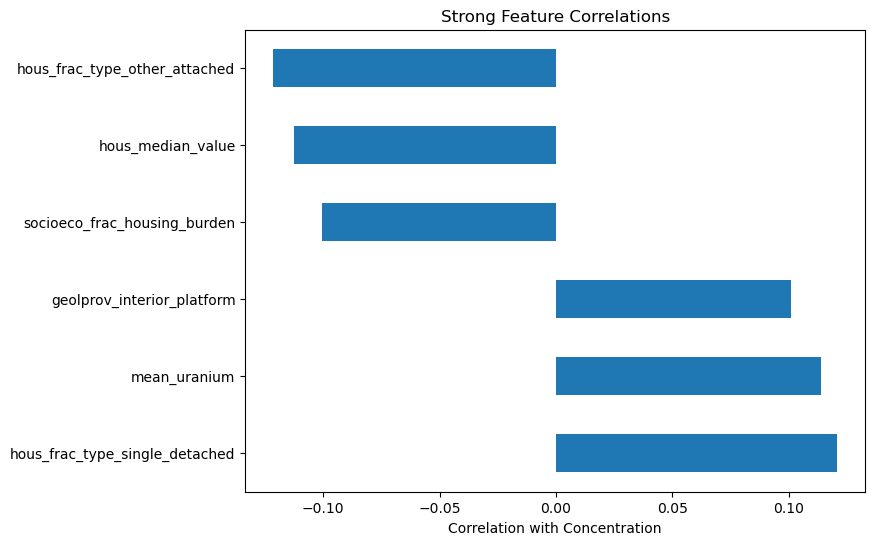

In [65]:
strong_corr.drop('concentration').plot(
    kind='barh',
    figsize=(8,6)
)

plt.xlabel("Correlation with Concentration")
plt.title("Strong Feature Correlations")
plt.show()

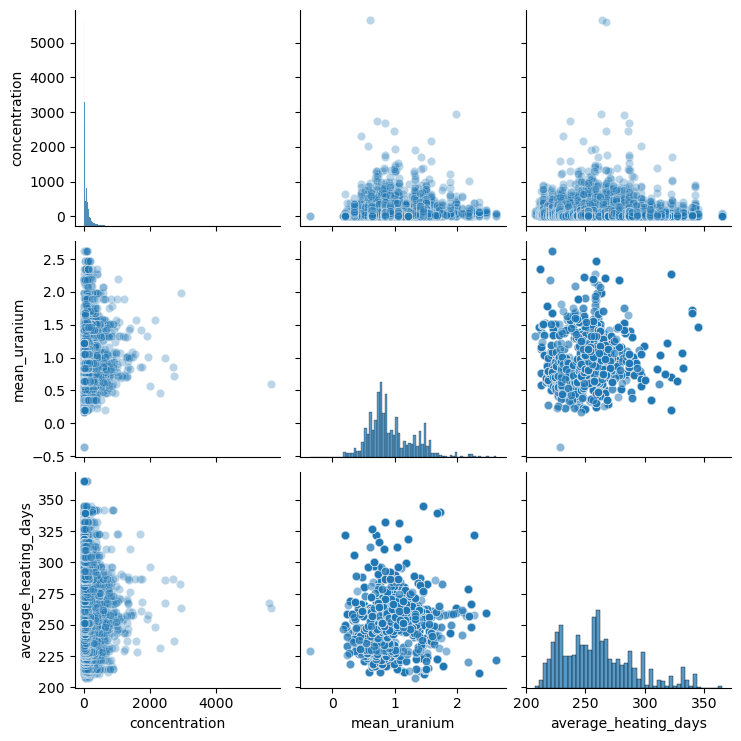

In [36]:
# pairwise relationships for a handful of features
sns.pairplot(df, vars=["concentration", "mean_uranium", "average_heating_days"], 
            height=2.5, plot_kws={"alpha":0.3})
plt.show()